IMPORTING USEFUL LIBRARIES

In [ ]:
import sys

# Step 1: Install gpjax (brings in numpyro, jax, etc.)
!{sys.executable} -m pip install -q gpjax

# Step 2: Patch numpyro's provenance.py for JAX 0.10.0 compatibility
# (xla_pmap_p was removed in JAX 0.10.0 but numpyro 0.20.1 still references it)
!sed -i 's/from jax.extend.core.primitives import call_p, closed_call_p, jit_p, xla_pmap_p/from jax.extend.core.primitives import call_p, closed_call_p, jit_p/' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

!sed -i 's/track_deps_rules\[xla_pmap_p\] = track_deps_call_rule//' \
    /usr/local/lib/python3.12/dist-packages/numpyro/ops/provenance.py

print("Patch applied. Now restart your session, then import gpjax.")

In [ ]:
import gpjax
print(gpjax.__version__)  # Works with modern JAX
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

0.18.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random, jacfwd, jacrev
from jax import lax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer import Predictive

import gpjax as gpx
from gpjax import kernels, mean_functions

import optax

import numpy as np
import scipy

print("JAX version:", jax.__version__)
print("NumPyro version:", numpyro.__version__)
print("GPJax version:", gpx.__version__)
print("Default backend:", jax.default_backend())


JAX version: 0.10.2
NumPyro version: 0.21.0
GPJax version: 0.18.0
Default backend: cpu


In [ ]:
import gpjax
print(gpjax.__version__)  # Works with modern JAX
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

0.18.0


FORWARD MODELING

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=np.arctan((x-A+(0.5*m))/(D))-np.arctan((x-A-(0.5*m))/(D))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D)*f1)-(d*f2)+f3+f4
    g=2*G*rho*f #in miligal
    return g
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
def g_n_anomaly(N,x,A,m,D,d,rho):
    u=0
    for i in range(N):
        v=g_anomaly(x,A[i],m[i],D[i],d[i],rho[i])
        u=u+v

    return u

In [ ]:
#Definng a new function g_n_anomaly to calculate summed gravity anomaly for n number of prisms
#Defining bottom depths of two layers by bd1 and bd2. Each element of bd1 representing bottom depth value of one prism. same for bd2 in meter
bd1=np.array([500,510,520,530,540,545,550,545,540,530,520,490,470,460,450,440,420,410,400,390,385,380,385,390,400,410,420,430,460,470])
bd2=np.array([800,790,780,770,760,755,750,755,760,770,780,810,830,840,850,860,880,890,900,910,915,920,915,910,900,890,880,870,850,830])
n= 30 #We are considering 30 prisms here
#surface value in meter
td=np.zeros(n)
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)
# Defining centre value of horizontal co-ordinate of each prism
#co=np.arange(-4500,4500,300)
co=np.linspace(-4350,4350,n)
# Defining width of each prism
wid=np.zeros(n)
for j in range(n):
    wid[j]= 300 # in meter

#USING LINEAR VARIATION OF DENSITY
den1_L=np.zeros(n)
for i in range(30):
    den1_L[i]=-100-i*3
den2_L=np.zeros(n)
for i in range(n):
    den2_L[i]=-220-i*2
#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
zs1[0]=bd1[0]
zs1[n]=bd1[n-1]
for i in range(1,n):
    zs1[i]=bd1[i]
#Creating z2 co-ordinate values for 2nd layer for each prism
zs2=np.zeros(n+1)
zs2[0]=bd2[0]-5
zs2[n]=bd2[n-1]+5
for i in range(1,n):
    zs2[i]=(bd2[i-1]+bd2[i])*0.5
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]
#Creating points for 1st layer
R1=np.zeros(((n+1),2))
for i in range(n+1):
    R1[i]=[xs[i],zs1[i]]

#Creating points for 1st layer
R1_1=np.zeros(((n+1),2))
for i in range(n):
    R1_1[i]=[xs[i+1],zs1[i]]
#Creating points for 2nd layer
R2=np.zeros(((n+1),2))
for i in range(n+1):
    R2[i]=[xs[i],zs2[i]]
#Creating points for 1st layer
R2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_1[i]=[xs[i+1],zs2[i]]

In [ ]:
#Defining "measure_func" function to calculate gravity anomaly for combined two layers in miligal with user defined station coordinates and above defined model parameters with some added random noise
def measure_func(x):
    return g_n_anomaly(n,x,co,wid,bd1,td,den1_L)+ g_n_anomaly(n,x,co,wid,bd2,bd1,den2_L)

In [ ]:
NUM_INIT_POINTS = 50 # number of observation points
X = np.linspace(-5000, 5000, NUM_INIT_POINTS)#Measurement points along the profile -5000 meter to 5000 meter
X_test = np.linspace(-5000, 5000, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #gravity anomaly with no noise added

In [ ]:
import tensorflow as tf
# Set seeds for reproducibility
SEED = 45
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.3, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.1, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.05 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.05 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.01)**2))+(b*((X*0.01)**3))+c)

#Adding noise to the gravity anomaly data

y = measure_func(X) + random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X_test)#interpolating between noisy observations at finer fintervals

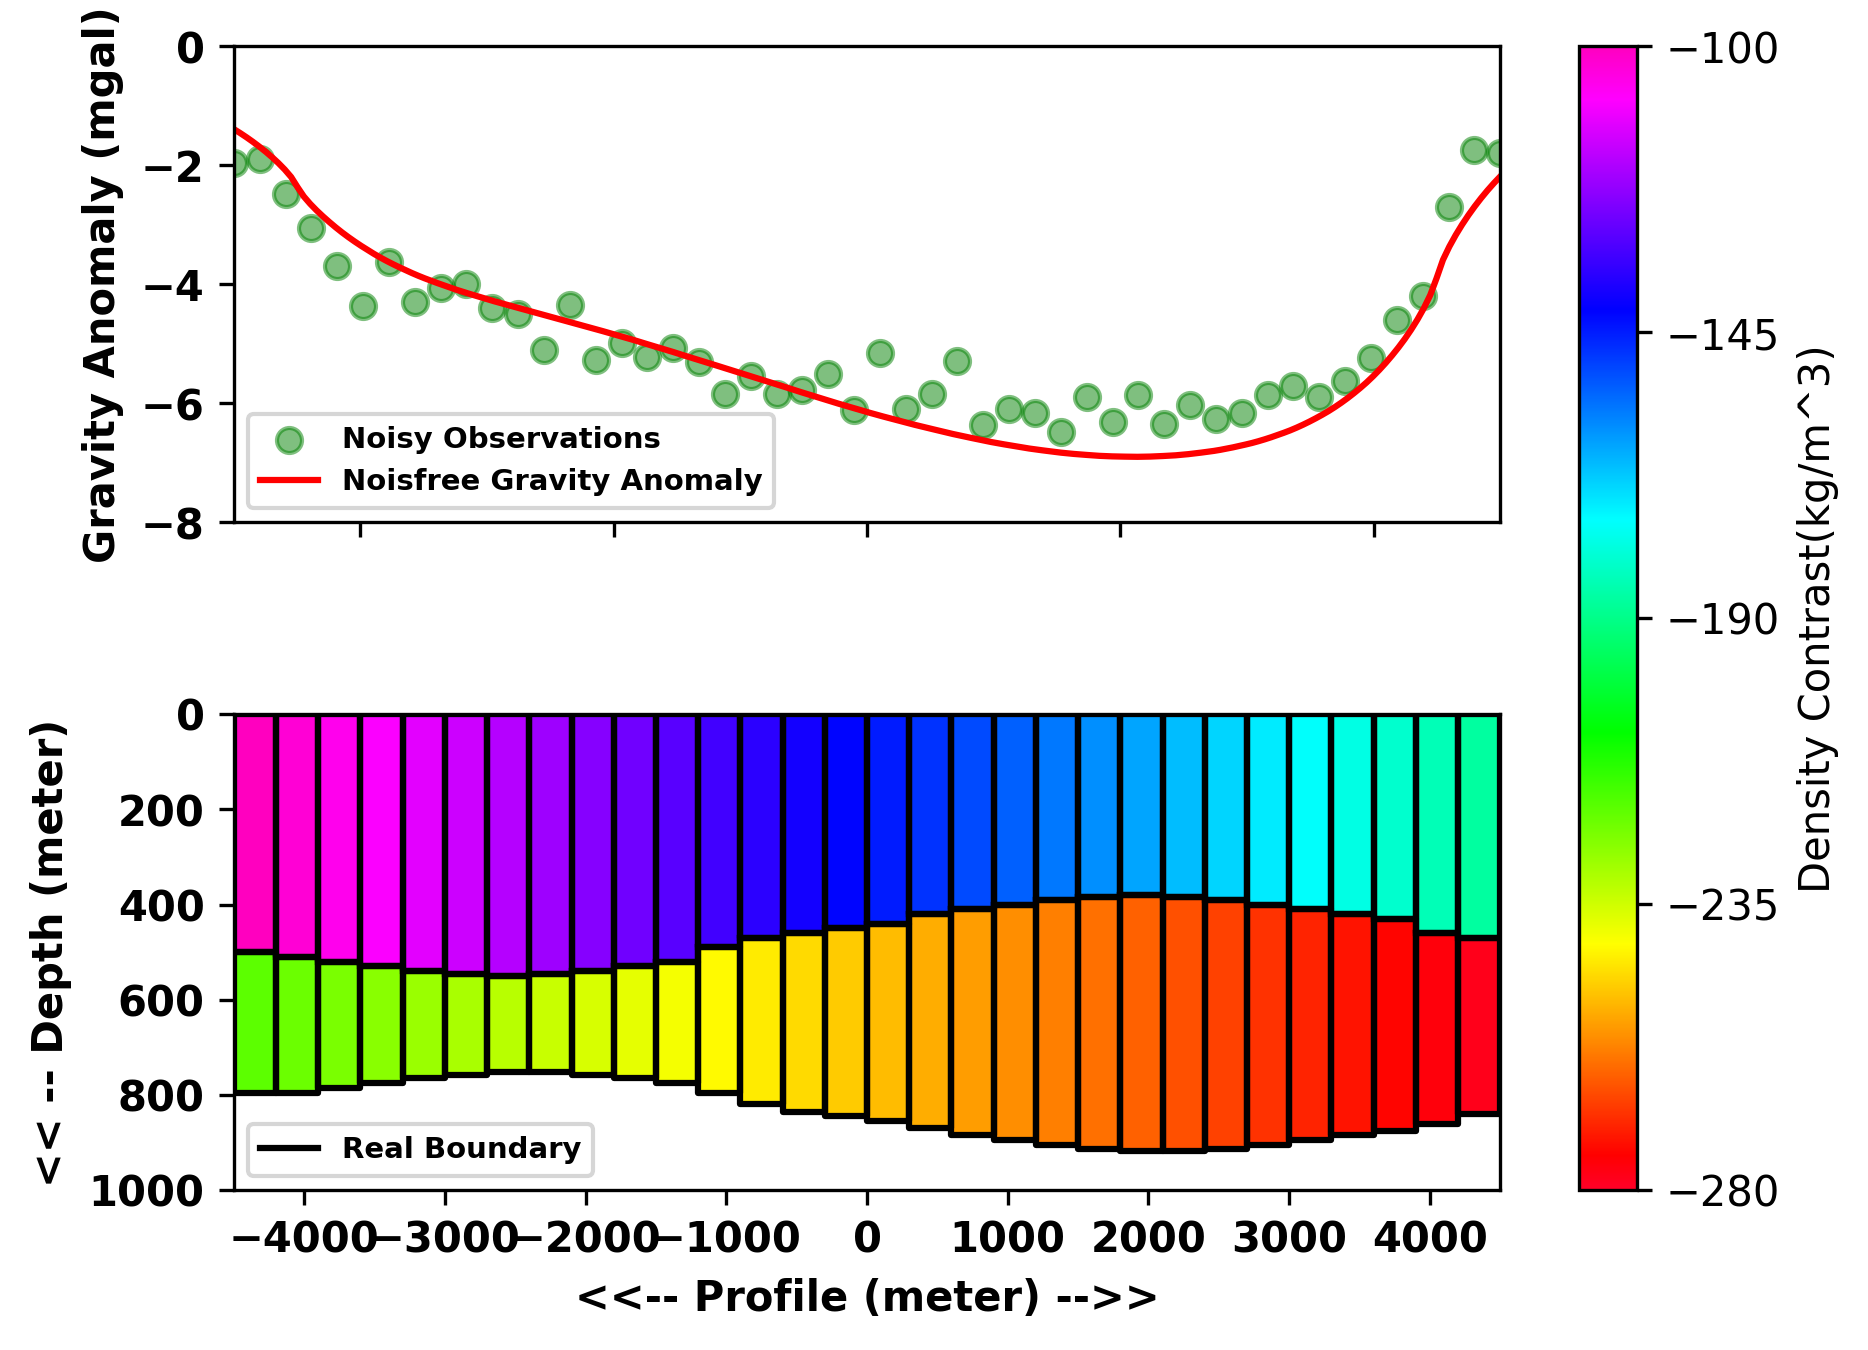

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axs = plt.subplots(2)
fig.dpi=300
fig.tight_layout(pad=2.5)
cmap_V= plt.get_cmap('gist_rainbow',1000)
maximum_V=-100#maximum density in kg per m^3 in colorscale
minimum_V=-280#minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density Contrast(kg/m^3)')
for i in range(n):
    #choosing color from the colorscale acc to the density value of each prism of layer 1
    index_value_V1 = (den1_L[i]-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing color from the colorscale acc to the density value of each prism of layer 2
    index_value_V2 = (den2_L[i]-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    #creating each prism using 4 corner co-ordinates
    coord1 = [R0[i], R0[i+1], R1_1[i], R1[i]]
    coord2 = [R1[i], R1_1[i], R2_1[i], R2[i]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0])
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1,ys1,'k') #plotting each prism of layer 1
    axs[1].plot(xs2,ys2,'k') #plotting each prism of layer 2
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism of layer 1 acc to its density value
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism of layer 2 acc to its density value
    axs[1].set_xlim(-4500,4500)
    axs[1].set_ylim(1000,0)
    axs[1].set_ylabel("<< -- Depth (meter)",fontsize=10,weight='bold')
    axs[1].set_xlim(-4500,4500)


axs[0].scatter(X,y,alpha=0.5, c='g', marker='o', label="Noisy Observations")#observed gravity anomaly at station points
axs[0].plot(X_test, ground_truth,  c='red', label="Truth Signal")#gravity anomaly at finer intervals without noise
axs[0].legend()
axs[0].set_ylim(-8,0)
axs[1].set_ylim(1000,0)
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
axs[1].set_xlabel("<<-- Profile (meter) -->>",fontsize=10,weight='bold')
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[1].get_xticklabels(), visible= True, weight='bold')
plt.setp(axs[1].get_yticklabels(), visible= True, weight='bold')
plt.setp(axs[0].get_yticklabels(), visible= True, weight='bold')
axs[0].set_xlim(-5000,5000)
legend_properties = {'weight':'bold','size':'7'}
axs[0].legend(['Noisy Observations','Noisfree Gravity Anomaly'],prop=legend_properties)
axs[1].legend(['Real Boundary'],prop=legend_properties)

## INVERSION

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict




In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


In [ ]:
# CUSTOM MATERN KERNEL FOR v=3/2
def custom_Matern_kernel(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

    # Example of a custom kernel prior for the above kernels
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters."""
    import numpyro.distributions as dist
    k_scale = numpyro.sample("k_scale",dist.HalfNormal(1))
    k_length = numpyro.sample("k_length",dist.LogNormal(0,1))
    return {"k_length": k_length, "k_scale": k_scale}


In [ ]:

import random
random.seed(42)
depth1_lo_bounds = [random.uniform(float(bd1[i])-200,float(bd1[i])-50) for i in range(n)]
depth1_hi_bounds = [random.uniform(float(bd1[i])+50,float(bd1[i])+200) for i in range(n)]

depth2_lo_bounds = [random.uniform(float(bd2[i])-200,float(bd2[i])-50) for i in range(n)]
depth2_hi_bounds = [random.uniform(float(bd2[i])+50,float(bd2[i])+200) for i in range(n)]

density1_lo_bounds = [random.uniform(float(den1_L[i])-20,float(den1_L[i])-10) for i in range(n)]
density1_hi_bounds = [random.uniform(float(den1_L[i])+10,float(den1_L[i])+20) for i in range(n)]

density2_lo_bounds = [random.uniform(float(den2_L[i])-20,float(den2_L[i])-10) for i in range(n)]
density2_hi_bounds = [random.uniform(float(den2_L[i])+10,float(den2_L[i])+20) for i in range(n)]

def Bayes_Inf_prior():
    params = {}
    for i in range(n):
        # ── Bottom depth prior ───────────────────────────────────
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}",
            dist.Uniform(depth1_lo_bounds[i], depth1_hi_bounds[i]))
        params[f"B_D2_{i+1}"] = numpyro.sample(
              f"B_D2_{i+1}",
              dist.Uniform(depth2_lo_bounds[i], depth2_hi_bounds[i]))
        params[f"density1_{i+1}"] = numpyro.sample(
            f"density1_{i+1}",
            dist.Uniform(density1_lo_bounds[i], density1_hi_bounds[i]))
        params[f"density2_{i+1}"] = numpyro.sample(
            f"density2_{i+1}",
            dist.Uniform(density2_lo_bounds[i], density2_hi_bounds[i]))

    return params


## Defining Mean Function
def Bayes_Inf(x,params):
    u=0
    for i in range(n):
        B_D1 = params[f"B_D1_{i+1}"] #bottom depth of each prism of layer 1 (model parameter to be inverted)
        density1 = params[f"density1_{i+1}"] #density of each prism of layer 1 (model parameter to be inverted)
        B_D2 = params[f"B_D2_{i+1}"] #bottom depth of each prism of layer 2 (model parameter to be inverted)
        density2 = params[f"density2_{i+1}"] #density of each prism of layer 1 (model parameter to be inverted)
        v=g_ano(x,co[i],wid[i],B_D1,td[i],density1) #calculatiin of anomaly for layer 1
        w=g_ano(x,co[i],wid[i],B_D2,B_D1,density2) #calculatiin of anomaly for layer 2
        u=u+v+w #summed up anomaly
    return u
def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Inf_prior()
    mean_vec    = Bayes_Inf(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)



In [ ]:
def gp_predict(rng_key, X_train, y_train, X_test, samples, n_samples=500):
    """
    Returns:
        y_pred     : (n_draws, N_test) - posterior means per draw
        y_sampled  : (n_draws, N_test) - posterior predictive samples
        pred_mean  : (N_test,)         - mean over posterior draaws
        pred_std   : (N_test,)         - std over posterior draws
    """
    jitter = 1e-6

    # Ensure 2D
    X_train = jnp.array(X_train).reshape(-1, 1) if X_train.ndim == 1 else X_train
    X_test  = jnp.array(X_test).reshape(-1, 1)  if X_test.ndim  == 1 else X_test
    x_train_1d = X_train[:, 0]
    x_test_1d  = X_test[:, 0]

    n_draws     = min(n_samples, samples["k_scale"].shape[0])
    all_means   = []
    all_samples = []

    for i in range(n_draws):
        # Extract posterior sample of kernel params
        k_scale   = samples["k_scale"][i]
        k_length  = samples["k_length"][i]
        noise_var = samples["noise_var"][i]

        # Build params dict for custom_Matern_kernel
        kernel_params = {
            "k_scale"  : k_scale,
            "k_length" : k_length
        }

        # Extract mean function params for this draw
        mean_params_i = {k: samples[k][i] for k in samples
                         if k not in ("k_scale", "k_length", "noise_var")}

        # ── Use custom_Matern_kernel directly ──────────────────────
        # K(X_train, X_train)
        K_tt = custom_Matern_kernel(X_train, X_train, kernel_params, noise=noise_var)

        # K(X_test, X_train)
        K_st = custom_Matern_kernel(X_test,  X_train, kernel_params, noise=0)

        # K(X_test, X_test)
        K_ss = custom_Matern_kernel(X_test,  X_test,  kernel_params, noise=0)
        K_ss += jitter * jnp.eye(X_test.shape[0])  # ensure PSD
        # ───────────────────────────────────────────────────────────

        # Posterior mean and covariance
        mean_train = Bayes_Inf(x_train_1d, mean_params_i)
        mean_test  = Bayes_Inf(x_test_1d,  mean_params_i)

        L     = jnp.linalg.cholesky(K_tt)
        alpha = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y_train - mean_train))
        mu_s  = mean_test + K_st @ alpha

        # Posterior covariance
        v     = jnp.linalg.solve(L, K_st.T)
        cov_s = K_ss - v.T @ v
        cov_s += jitter * jnp.eye(X_test.shape[0])  # ensure PSD

        # Draw from posterior predictive
        rng_key, subkey = jax.random.split(rng_key)
        y_s = jax.random.multivariate_normal(subkey, mu_s, cov_s)

        all_means.append(mu_s)
        all_samples.append(y_s)

    y_sampled = jnp.stack(all_samples)  # (n_draws, N_test)
    y_pred    = jnp.stack(all_means)    # (n_draws, N_test)
    pred_mean = y_pred.mean(0)          # (N_test,)
    pred_std  = y_pred.std(0)           # (N_test,)

    return y_pred, y_sampled, pred_mean, pred_std

STRUCTURED GP

In [ ]:
def gp_model(X, y=None):
    X    = jnp.array(X).reshape(-1, 1) if X.ndim == 1 else X
    x_1d = X[:, 0]

    kernel_params = custom_kernel_prior()
    k_scale  = kernel_params["k_scale"]
    k_length = kernel_params["k_length"]

    noise_var = numpyro.sample("noise_var", dist.HalfNormal(0.1))

    mean_params = Bayes_Inf_prior()
    mean_vec    = Bayes_Inf(x_1d, mean_params)

    K = custom_Matern_kernel(
        X, X,
        params={"k_scale": k_scale, "k_length": k_length},
        noise=noise_var
    )

    numpyro.sample("y", dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K), obs=y)

# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model), num_warmup=2000, num_samples=100)
mcmc1.run(rng_key, X, y)
samples1 = mcmc1.get_samples()


In [ ]:
# Run MCMC
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1 = MCMC(NUTS(gp_model), num_warmup=2000, num_samples=100)
mcmc1.run(rng_key, X, y)
samples1 = mcmc1.get_samples()

In [ ]:
#Storing the inverted results of narrow prior range

params1 = mcmc1.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths1 = np.zeros(n)
for i in range(n):
    top_inverted_depths1[i] = params1[f"B_D1_{i+1}"].mean()

bottom_inverted_depths1 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths1[i] = params1[f"B_D2_{i+1}"].mean()

top_density1 = np.zeros(n)
for i in range(n):
    top_density1[i] = params1[f"density1_{i+1}"].mean()
bottom_density1 = np.zeros(n)
for i in range(n):
    bottom_density1[i] = params1[f"density2_{i+1}"].mean()

top_inverted_depths1_min=np.zeros(n)
top_inverted_depths1_max=np.zeros(n)
for i in range(n):
    top_inverted_depths1_min[i]=params1[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths1_max[i]=params1[f"B_D1_{i+1}"].max()

bottom_inverted_depths1_min=np.zeros(n)
bottom_inverted_depths1_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths1_min[i]=params1[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths1_max[i]=params1[f"B_D2_{i+1}"].max()
top_density1_min=np.zeros(n)
for i in range(n):
    top_density1_min[i]=params1[f"density1_{i+1}"].min()
top_density1_max=np.zeros(n)
for i in range(n):
    top_density1_max[i]=params1[f"density1_{i+1}"].max()
bottom_density1_min=np.zeros(n)
for i in range(n):
    bottom_density1_min[i]=params1[f"density2_{i+1}"].min()
bottom_density1_max=np.zeros(n)
for i in range(n):
    bottom_density1_max[i]=params1[f"density2_{i+1}"].max()
X_test = jnp.linspace(X.min(), X.max(), 100)

y_pred1, y_sampled1, pred_mean1, pred_std1 = gp_predict(
    rng_key_predict, X, y, X_test, samples1, n_samples=50
)

#####
pred_mean1 = np.array(y_sampled1.mean(0))
pred_std1  = np.array(y_sampled1.std(0))
top_density1_std=np.zeros(n)
for i in range(n):
    top_density1_std[i]=params1[f"density1_{i+1}"].std()
bottom_density1_std=np.zeros(n)
for i in range(n):
    bottom_density1_std[i]=params1[f"density2_{i+1}"].std()

ACTIVE LEARNING

In [ ]:
#Choosing random values for initial points within a range(geologically & geophysically justified)
import random
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
PARAMS={}

for i in range(n):
    PARAMS[f"B_D1_{i+1}"] = random.uniform(top_inverted_depths1_min[i],top_inverted_depths1_max[i])
    PARAMS[f"B_D2_{i+1}"] = random.uniform(bottom_inverted_depths1_min[i],bottom_inverted_depths1_max[i])
    PARAMS[f"density1_{i+1}"] = random.uniform(top_density1_min[i],top_density1_max[i])
    PARAMS[f"density2_{i+1}"] = random.uniform(bottom_density1_min[i],bottom_density1_max[i])

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", True)

# ── Initial setup (same as before) ──────────────────────────
SEED = 42
np.random.seed(SEED)
N_POLY_COEFFS=4
# Starting observations
Xo = np.array(X).flatten().copy()
yo = np.array(y).flatten().copy()

X_test_AL = np.linspace(-5000, 5000, 100)   # candidate points for active learning

# ── Uncertainty Exploration acquisition function ─────────────
def uncertainty_exploration(pred_std):
    """Returns index of point with highest posterior std."""
    return np.argmax(pred_std)


# ── Forward model at a single point (for active learning) ────
def forward_at_point(x_new, params_mean):
    """
    Evaluate the forward model at a single new x location
    using the posterior mean parameters.
    Used to generate a 'measurement' at the suggested point.
    """
    x_arr = jnp.array([x_new])
    return float(Bayes_Inf(x_arr, params_mean)[0])


# ── Active Learning Loop ─────────────────────────────────────
n_exploration_steps = 5   # same as your original

rng_key = jax.random.PRNGKey(SEED)
rng_key, rng_key_predict = jax.random.split(rng_key)

for step in range(n_exploration_steps):
    print(f"\n{'='*50}")
    print(f"Exploration step {step + 1}")
    print(f"{'='*50}")
    print(f"Current number of observations: {len(Xo)}")

    # ── Step 1: Fit GP model on current observations ─────────
    X_jnp = jnp.array(Xo).reshape(-1, 1)
    y_jnp = jnp.array(yo)

    mcmc_al = MCMC(
        NUTS(gp_model),
        num_warmup=2000,
        num_samples=50,
        num_chains=1,
        progress_bar=True
    )
    mcmc_al.run(rng_key, X_jnp, y_jnp)
    samples_al = mcmc_al.get_samples()

    # Print summary
    print(f"\nPosterior summary — step {step + 1}:")
    inverted_depths1_al = np.array([samples_al[f"B_D1_{i+1}"].mean() for i in range(n)])
    inverted_depths2_al = np.array([samples_al[f"B_D2_{i+1}"].mean() for i in range(n)])
    density1_al = np.array([samples_al[f"density1_{i+1}"].mean() for i in range(n)])
    density2_al = np.array([samples_al[f"density2_{i+1}"].mean() for i in range(n)])

    print(f"  Mean depth range: [{inverted_depths1_al.min():.1f}, {inverted_depths1_al.max():.1f}] m")
    print(f"  Mean depth range: [{inverted_depths2_al.min():.1f}, {inverted_depths2_al.max():.1f}] m")

    # ── Step 2: Predict over candidate points ─────────────────
    X_test_jnp = jnp.array(X_test_AL).reshape(-1, 1)

    _, y_sampled_al, pred_mean_al, pred_std_al = gp_predict(
        rng_key_predict, X_jnp, y_jnp, X_test_jnp, samples_al, n_samples=75
    )
    pred_mean_al = np.array(y_sampled_al.mean(0))
    pred_std_al  = np.array(y_sampled_al.std(0))

    # ── Step 3: Uncertainty Exploration — find next point ─────
    next_idx   = uncertainty_exploration(pred_std_al)
    next_point = X_test_AL[next_idx]
    print(f"\nNext suggested point: x = {next_point:.2f} m")
    print(f"  Uncertainty at that point: {pred_std_al[next_idx]:.4f} mGal")

    # ── Step 4: Generate 'measurement' at new point ───────────
    # Reconstruct posterior mean params for forward evaluation
    params_mean = {}
    for i in range(n):
        params_mean[f"B_D1_{i+1}"] = jnp.array(samples_al[f"B_D1_{i+1}"].mean())
        params_mean[f"B_D2_{i+1}"] = jnp.array(samples_al[f"B_D2_{i+1}"].mean())
        params_mean[f"density1_{i+1}"] = jnp.array(samples_al[f"density1_{i+1}"].mean())
        params_mean[f"density2_{i+1}"] = jnp.array(samples_al[f"density2_{i+1}"].mean())

    # Evaluate forward model at new point + add noise (same noise model as original)
    y_new_clean = forward_at_point(next_point, params_mean)

    # Add same noise as original observations

    y_new = y_new_clean

    print(f"  Measured value: {y_new:.4f} mGal")

    # ── Step 5: Append new observation ───────────────────────
    Xo = np.append(Xo, next_point)
    yo = np.append(yo, y_new)

    # Update rng keys for next iteration
    rng_key, rng_key_predict = jax.random.split(rng_key)

print(f"\nActive learning complete.")
print(f"Total observations: {len(Xo)} (started with {len(np.array(X).flatten())})")




# ── Final full MCMC on all observations ──────────────────────
print("\nRunning final MCMC on all observations...")

X_final = jnp.array(Xo).reshape(-1, 1)
y_final = jnp.array(yo)

mcmc3 = MCMC(
    NUTS(gp_model),
    num_warmup=2000,
    num_samples=50,
    num_chains=1,
    progress_bar=True
)
mcmc3.run(rng_key, X_final, y_final)
samples3 = mcmc3.get_samples()
#####################################








################################################################
# ── Plot active learning progression ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.dpi = 300

original_X = np.array(X).flatten()
added_X    = Xo[len(original_X):]   # the points added during active learning

ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)
ax.scatter(added_X, yo[len(original_X):],
           marker='*', s=100, c='red', label='Active learning points', zorder=3)

# Plot final prediction
X_test_final_jnp = jnp.array(X_test_AL).reshape(-1, 1)
_, y_samp_f, pred_mean_f, pred_std_f = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp, samples3, n_samples=50
)
pred_mean_f = np.array(y_samp_f.mean(0))
pred_std_f  = np.array(y_samp_f.std(0))

ax.plot(X_test_AL, pred_mean_f, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL,
                pred_mean_f - pred_std_f,
                pred_mean_f + pred_std_f,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000, 5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("active_learning_progression.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

jax.config.update("jax_enable_x64", True)

# ── Initial setup ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
N_POLY_COEFFS = 4

Xo = np.array(X).flatten().copy()
yo = np.array(y).flatten().copy()

X_test_AL = np.linspace(-5000, 5000, 100)

# ── Storage for tracking improvement across steps ──────────────
history = {
    "step":          [],
    "n_obs":         [],
    "mean_std":      [],
    "max_std":       [],
    "pred_means":    [],
    "pred_stds":     [],
    "added_X":       [],
    "added_y":       [],
    # --- parameter histories (list of length-n arrays per step) ---
    "depth1_mean":   [],   # posterior mean of B_D1 per body
    "depth1_std":    [],   # posterior std  of B_D1 per body
    "depth2_mean":   [],
    "depth2_std":    [],
    "density1_mean": [],
    "density1_std":  [],
    "density2_mean": [],
    "density2_std":  [],
}

# ── Colour palette for bodies ──────────────────────────────────
BODY_COLORS = plt.cm.tab10.colors   # up to 10 bodies

# ── Acquisition function ───────────────────────────────────────
def uncertainty_exploration(pred_std):
    return np.argmax(pred_std)

# ── Forward model at a single point ───────────────────────────
def forward_at_point(x_new, params_mean):
    x_arr = jnp.array([x_new])
    return float(Bayes_Inf(x_arr, params_mean)[0])

# ── Figure layout: n_steps rows × 4 columns ───────────────────
#   Col 0 → GP fit + uncertainty band
#   Col 1 → Acquisition function (posterior std curve)
#   Col 2 → Inverted depth evolution   (B_D1 & B_D2)
#   Col 3 → Inverted density evolution (ρ1  & ρ2)
n_exploration_steps = 5
original_X = np.array(X).flatten()
original_y = np.array(y).flatten()

fig_steps = plt.figure(figsize=(22, 4.2 * n_exploration_steps), dpi=130)
fig_steps.suptitle(
    "Active Learning — Step-by-Step Model & Parameter Improvement",
    fontsize=14, fontweight='bold', y=1.005
)

outer_gs = gridspec.GridSpec(
    n_exploration_steps, 4,
    figure=fig_steps,
    wspace=0.38, hspace=0.55,
    width_ratios=[2.2, 1.8, 1.8, 1.8]   # GP fit gets a bit more room
)

rng_key = jax.random.PRNGKey(SEED)
rng_key, rng_key_predict = jax.random.split(rng_key)

# ── Helper: draw running parameter evolution up to current step ─
def _plot_param_evolution(ax, step_idx, means_history, stds_history,
                          param_label, ylabel, color_offset=0):
    """
    Draws mean ± 1σ for each body across all steps seen so far.
    means_history : list of 1-D arrays (one array per step, length n)
    """
    steps_so_far = np.arange(1, step_idx + 2)   # steps 1 … current
    for body_idx in range(n):
        col = BODY_COLORS[(body_idx + color_offset) % len(BODY_COLORS)]
        means = np.array([means_history[s][body_idx] for s in range(step_idx + 1)])
        stds  = np.array([stds_history[s][body_idx]  for s in range(step_idx + 1)])

        ax.plot(steps_so_far, means, 'o-', color=col,
                linewidth=1.8, markersize=5, label=f'Body {body_idx+1}')
        ax.fill_between(steps_so_far,
                        means - stds, means + stds,
                        color=col, alpha=0.18)

    ax.set_xlim(0.5, n_exploration_steps + 0.5)
    ax.set_xticks(np.arange(1, n_exploration_steps + 1))
    ax.set_xlabel("Exploration Step", fontsize=8, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8, fontweight='bold')
    ax.set_title(param_label, fontsize=8, fontweight='bold')
    ax.legend(fontsize=7, loc='best', ncol=1)
    ax.grid(True, alpha=0.3)

    # Shade future steps grey
    if step_idx < n_exploration_steps - 1:
        ax.axvspan(step_idx + 1.5, n_exploration_steps + 0.5,
                   color='grey', alpha=0.08, label='_nolegend_')

# ── Active Learning Loop ───────────────────────────────────────
for step in range(n_exploration_steps):
    print(f"\n{'='*50}")
    print(f"Exploration step {step + 1}")
    print(f"{'='*50}")
    print(f"Current number of observations: {len(Xo)}")

    # ── Step 1: Fit GP on current observations ─────────────────
    X_jnp = jnp.array(Xo).reshape(-1, 1)
    y_jnp = jnp.array(yo)

    mcmc_al = MCMC(
        NUTS(gp_model),
        num_warmup=1000,
        num_samples=50,
        num_chains=1,
        progress_bar=True
    )
    mcmc_al.run(rng_key, X_jnp, y_jnp)
    samples_al = mcmc_al.get_samples()

    # ── Posterior parameter statistics ─────────────────────────
    d1_mean = np.array([samples_al[f"B_D1_{i+1}"].mean()  for i in range(n)])
    d1_std  = np.array([samples_al[f"B_D1_{i+1}"].std()   for i in range(n)])
    d2_mean = np.array([samples_al[f"B_D2_{i+1}"].mean()  for i in range(n)])
    d2_std  = np.array([samples_al[f"B_D2_{i+1}"].std()   for i in range(n)])
    rho1_mean = np.array([samples_al[f"density1_{i+1}"].mean() for i in range(n)])
    rho1_std  = np.array([samples_al[f"density1_{i+1}"].std()  for i in range(n)])
    rho2_mean = np.array([samples_al[f"density2_{i+1}"].mean() for i in range(n)])
    rho2_std  = np.array([samples_al[f"density2_{i+1}"].std()  for i in range(n)])

    print(f"\nPosterior summary — step {step + 1}:")
    print(f"  B_D1 mean range : [{d1_mean.min():.1f}, {d1_mean.max():.1f}] m")
    print(f"  B_D2 mean range : [{d2_mean.min():.1f}, {d2_mean.max():.1f}] m")

    # ── Step 2: Predict over candidate points ──────────────────
    X_test_jnp = jnp.array(X_test_AL).reshape(-1, 1)

    _, y_sampled_al, pred_mean_al, pred_std_al = gp_predict(
        rng_key_predict, X_jnp, y_jnp, X_test_jnp, samples_al, n_samples=75
    )
    pred_mean_al = np.array(y_sampled_al.mean(0))
    pred_std_al  = np.array(y_sampled_al.std(0))

    # ── Step 3: Acquisition — next point ──────────────────────
    next_idx   = uncertainty_exploration(pred_std_al)
    next_point = X_test_AL[next_idx]
    print(f"\nNext suggested point : x = {next_point:.2f} m")
    print(f"  Uncertainty        : {pred_std_al[next_idx]:.4f} mGal")

    # ── Step 4: Forward model measurement ─────────────────────
    params_mean = {}
    for i in range(n):
        params_mean[f"B_D1_{i+1}"]     = jnp.array(d1_mean[i])
        params_mean[f"B_D2_{i+1}"]     = jnp.array(d2_mean[i])
        params_mean[f"density1_{i+1}"] = jnp.array(rho1_mean[i])
        params_mean[f"density2_{i+1}"] = jnp.array(rho2_mean[i])

    y_new = forward_at_point(next_point, params_mean)
    print(f"  Measured value     : {y_new:.4f} mGal")

    # ── Save history ───────────────────────────────────────────
    history["step"].append(step + 1)
    history["n_obs"].append(len(Xo))
    history["mean_std"].append(float(pred_std_al.mean()))
    history["max_std"].append(float(pred_std_al[next_idx]))
    history["pred_means"].append(pred_mean_al.copy())
    history["pred_stds"].append(pred_std_al.copy())
    history["added_X"].append(next_point)
    history["added_y"].append(y_new)
    history["depth1_mean"].append(d1_mean);   history["depth1_std"].append(d1_std)
    history["depth2_mean"].append(d2_mean);   history["depth2_std"].append(d2_std)
    history["density1_mean"].append(rho1_mean); history["density1_std"].append(rho1_std)
    history["density2_mean"].append(rho2_mean); history["density2_std"].append(rho2_std)

    # ══════════════════════════════════════════════════════════
    #  Per-step subplots
    # ══════════════════════════════════════════════════════════
    ax_fit = fig_steps.add_subplot(outer_gs[step, 0])
    ax_acq = fig_steps.add_subplot(outer_gs[step, 1])


    # ── Col 0: GP fit ──────────────────────────────────────────
    ax_fit.fill_between(X_test_AL,
                        pred_mean_al - 2*pred_std_al,
                        pred_mean_al + 2*pred_std_al,
                        color='steelblue', alpha=0.10, label='±2σ')
    ax_fit.fill_between(X_test_AL,
                        pred_mean_al - pred_std_al,
                        pred_mean_al + pred_std_al,
                        color='steelblue', alpha=0.25, label='±1σ')
    ax_fit.plot(X_test_AL, pred_mean_al, '-', color='steelblue',
                linewidth=2, label='Predicted mean')
    ax_fit.scatter(original_X, original_y, marker='x', s=40, c='black',
                   zorder=4, label='Original obs.')
    if step > 0:
        prev_X = np.array(history["added_X"][:-1])
        prev_y = np.array(history["added_y"][:-1])
        ax_fit.scatter(prev_X, prev_y, marker='*', s=100,
                       c='orange', zorder=5, label='Prev AL pts')
    ax_fit.axvline(next_point, color='red', linestyle='--',
                   linewidth=1.2, alpha=0.7)
    ax_fit.scatter([next_point], [y_new], marker='*', s=200,
                   c='red', zorder=6,
                   label=f'New pt ({next_point:.0f} m)')
    ax_fit.set_xlim(-5000, 5000)
    ax_fit.set_xlabel("Profile (m)", fontsize=8, fontweight='bold')
    ax_fit.set_ylabel("Gravity Anomaly (mGal)", fontsize=8, fontweight='bold')
    ax_fit.set_title(
        f"Step {step+1}  |  GP Fit  |  N={len(Xo)}  "
        f"|  Mean σ={pred_std_al.mean():.4f}",
        fontsize=8, fontweight='bold'
    )
    ax_fit.legend(fontsize=6.5, ncol=2, loc='upper right')
    ax_fit.grid(True, alpha=0.3)

    # ── Col 1: Acquisition function ────────────────────────────
    ax_acq.plot(X_test_AL, pred_std_al, color='darkorange',
                linewidth=2, label='Posterior std σ(x)')
    ax_acq.fill_between(X_test_AL, 0, pred_std_al,
                        color='darkorange', alpha=0.15)
    ax_acq.axvline(next_point, color='red', linestyle='--', linewidth=1.5,
                   label=f'Selected\nx={next_point:.0f} m\nσ={pred_std_al[next_idx]:.4f}')
    if step > 0:
        for px in history["added_X"][:-1]:
            ax_acq.axvline(px, color='orange', linestyle=':', linewidth=1, alpha=0.6)
    ax_acq.set_xlim(-5000, 5000)
    ax_acq.set_ylim(bottom=0)
    ax_acq.set_xlabel("Profile (m)", fontsize=8, fontweight='bold')
    ax_acq.set_ylabel("Posterior Std (mGal)", fontsize=8, fontweight='bold')
    ax_acq.set_title(f"Step {step+1}  |  Acquisition Function",
                     fontsize=8, fontweight='bold')
    ax_acq.legend(fontsize=7, loc='upper right')
    ax_acq.grid(True, alpha=0.3)


plt.show()

print(f"\nActive learning complete.")
print(f"Total observations: {len(Xo)} (started with {len(original_X)})")


# ── Final MCMC on all observations ────────────────────────────
print("\nRunning final MCMC on all observations...")

X_final = jnp.array(Xo).reshape(-1, 1)
y_final = jnp.array(yo)

mcmc3 = MCMC(
    NUTS(gp_model),
    num_warmup=2000,
    num_samples=50,
    num_chains=1,
    progress_bar=True
)
mcmc3.run(rng_key, X_final, y_final)
samples3 = mcmc3.get_samples()


# ══════════════════════════════════════════════════════════════
#  Summary figure 1 — Uncertainty reduction
# ══════════════════════════════════════════════════════════════
fig_summ, axes_s = plt.subplots(1, 2, figsize=(13, 4), dpi=130)
fig_summ.suptitle("Active Learning — Uncertainty Reduction Summary",
                  fontsize=12, fontweight='bold')

steps_arr = np.array(history["step"])
axes_s[0].plot(steps_arr, history["mean_std"], 'o-', color='steelblue',
               linewidth=2, markersize=7, label='Mean σ (all candidates)')
axes_s[0].plot(steps_arr, history["max_std"], 's--', color='red',
               linewidth=2, markersize=7, label='Max σ (selected point)')
axes_s[0].set_xlabel("Exploration Step", fontweight='bold')
axes_s[0].set_ylabel("Posterior Std (mGal)", fontweight='bold')
axes_s[0].set_title("Uncertainty vs. Step", fontweight='bold')
axes_s[0].set_xticks(steps_arr)
axes_s[0].legend(fontsize=9)
axes_s[0].grid(True, alpha=0.3)

cmap = plt.cm.coolwarm_r
for i, (s, std_curve) in enumerate(zip(steps_arr, history["pred_stds"])):
    col = cmap(i / max(len(steps_arr) - 1, 1))
    axes_s[1].plot(X_test_AL, std_curve, color=col, linewidth=1.8,
                   alpha=0.85, label=f'Step {s}')
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=1, vmax=n_exploration_steps))
sm.set_array([])
cbar = fig_summ.colorbar(sm, ax=axes_s[1], pad=0.02)
cbar.set_label("Exploration Step", fontsize=9)
axes_s[1].set_xlim(-5000, 5000); axes_s[1].set_ylim(bottom=0)
axes_s[1].set_xlabel("Profile (m)", fontweight='bold')
axes_s[1].set_ylabel("Posterior Std (mGal)", fontweight='bold')
axes_s[1].set_title("Uncertainty Curves (Dark→Early, Light→Late)", fontweight='bold')
axes_s[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_reduction_summary.png", dpi=130, bbox_inches='tight')
plt.show()




# ══════════════════════════════════════════════════════════════
#  Summary figure 3 — Final GP prediction
# ══════════════════════════════════════════════════════════════
fig_final, ax_f = plt.subplots(figsize=(11, 4), dpi=130)

X_test_final_jnp = jnp.array(X_test_AL).reshape(-1, 1)
_, y_samp_f, _, _ = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp, samples3, n_samples=50
)
pred_mean_f = np.array(y_samp_f.mean(0))
pred_std_f  = np.array(y_samp_f.std(0))

ax_f.fill_between(X_test_AL,
                  pred_mean_f - 2*pred_std_f, pred_mean_f + 2*pred_std_f,
                  color='red', alpha=0.08, label='Final ±2σ')
ax_f.fill_between(X_test_AL,
                  pred_mean_f - pred_std_f, pred_mean_f + pred_std_f,
                  color='red', alpha=0.20, label='Final ±1σ')
ax_f.plot(X_test_AL, pred_mean_f, '--', color='red',
          linewidth=2, label='Final predicted mean')
ax_f.scatter(original_X, original_y, marker='x', s=40, c='black',
             zorder=4, label='Original observations')
ax_f.scatter(np.array(history["added_X"]), np.array(history["added_y"]),
             marker='*', s=160, c='red', zorder=5,
             label='Active learning points')
ax_f.set_xlim(-5000, 5000)
ax_f.set_xlabel("Profile (m)", fontweight='bold')
ax_f.set_ylabel("Gravity Anomaly (mGal)", fontweight='bold')
ax_f.set_title("Final GP Prediction After Active Learning", fontweight='bold')
ax_f.legend(fontsize=9)
ax_f.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("final_prediction.png", dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
#Storing the inverted results of Narrow prior range

params3 = mcmc3.get_samples()

# Inverted bottom depths (one per prism)
top_inverted_depths3 = np.zeros(n)
for i in range(n):
    top_inverted_depths3[i] = params3[f"B_D1_{i+1}"].mean()

bottom_inverted_depths3 = np.zeros(n)
for i in range(n):
    bottom_inverted_depths3[i] = params3[f"B_D2_{i+1}"].mean()

top_density3 = np.zeros(n)
for i in range(n):
    top_density3[i] = params3[f"density1_{i+1}"].mean()
bottom_density3 = np.zeros(n)
for i in range(n):
    bottom_density3[i] = params3[f"density2_{i+1}"].mean()



top_inverted_depths3_min=np.zeros(n)
top_inverted_depths3_max=np.zeros(n)
for i in range(n):
    top_inverted_depths3_min[i]=params3[f"B_D1_{i+1}"].min()
for i in range(n):
    top_inverted_depths3_max[i]=params3[f"B_D1_{i+1}"].max()

bottom_inverted_depths3_min=np.zeros(n)
bottom_inverted_depths3_max=np.zeros(n)
for i in range(n):
    bottom_inverted_depths3_min[i]=params3[f"B_D2_{i+1}"].min()
for i in range(n):
    bottom_inverted_depths3_max[i]=params3[f"B_D2_{i+1}"].max()

top_density3_min=np.zeros(n)
for i in range(n):
    top_density3_min[i]=params3[f"density1_{i+1}"].min()
top_density3_max=np.zeros(n)
for i in range(n):
    top_density3_max[i]=params3[f"density1_{i+1}"].max()
bottom_density3_min=np.zeros(n)
for i in range(n):
    bottom_density3_min[i]=params3[f"density2_{i+1}"].min()
bottom_density3_max=np.zeros(n)
for i in range(n):
    bottom_density3_max[i]=params3[f"density2_{i+1}"].max()
top_density3_std=np.zeros(n)
for i in range(n):
    top_density3_std[i]=params3[f"density1_{i+1}"].std()
bottom_density3_std=np.zeros(n)
for i in range(n):
    bottom_density3_std[i]=params3[f"density2_{i+1}"].std()

In [ ]:
#Storing the inverted results

B_D1_act_2=np.zeros(n)
B_D2_act_2=np.zeros(n)
density1_act=np.zeros(n)
density2_act=np.zeros(n)
for i in range(n):
    B_D1_act_2[i]=top_inverted_depths3[i]

for i in range(n):
    B_D2_act_2[i]=bottom_inverted_depths3[i]

for i in range(n):
    density1_act[i]=top_density3[i]
for i in range(n):
    density2_act[i]=bottom_density3[i]


##Creating points from Inverted results##

#Creating x co-ordinates
xs_stra_2=np.zeros(n+1)
xs_stra_2[0]=co[0]-(wid[0]*0.5)
xs_stra_2[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs_stra_2[i]=co[i-1]+(0.5*wid[i-1])
#Creating bottom Co-ordinates for 1st layer
zs1_stra_2=np.zeros(n+1)
zs1_stra_2[0]=B_D1_act_2[0]-5
zs1_stra_2[n]=B_D1_act_2[n-1]+5
for i in range(1,n):
    zs1_stra_2[i]=(B_D1_act_2[i-1]+B_D1_act_2[i])*0.5
#Creating bottom Co-ordinates for second layer
zs2_stra_2=np.zeros(n+1)
zs2_stra_2[0]=B_D2_act_2[0]-5
zs2_stra_2[n]=B_D2_act_2[n-1]+5
for i in range(1,n):
    zs2_stra_2[i]=(B_D2_act_2[i-1]+B_D2_act_2[i])*0.5
#Creating points for ground layer
zs0_stra_2=np.zeros(n+1)
R0_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R0_stra_2[i]=[xs_stra_2[i],zs0_stra_2[i]]
#Creating bottom points for 1st layer
R1_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R1_stra_2[i]=[xs_stra_2[i],zs1_stra_2[i]]
R1_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R1_stra_2_1[i]=[xs_stra_2[i+1],zs1_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2=np.zeros(((n+1),2))
for i in range(n+1):
    R2_stra_2[i]=[xs_stra_2[i],zs2_stra_2[i]]
#Creating bottom points for 2nd layer
R2_stra_2_1=np.zeros(((n+1),2))
for i in range(n):
    R2_stra_2_1[i]=[xs_stra_2[i+1],zs2_stra_2[i]]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Plot active learning progression ─────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(10, 10)) # Use plt.subplots to get fig and axs array
fig.dpi = 300

# First subplot (Gravity Anomaly)
ax = axs[0] # Assign axs[0] to ax for consistency with existing code

original_X = np.array(X).flatten()
added_X1    = Xo[len(original_X):]   # the points added during active learning
added_y1    = yo[len(original_X):]
X_test_AL1 = X_test_AL
X_final1 = X_final
y_final1 = y_final
y_samp_f1 = y_samp_f
ax.scatter(original_X, np.array(y).flatten(),
           marker='x', s=30, c='k', label='Original observations', zorder=2)

# Plot final prediction
X_test_final_jnp1 = jnp.array(X_test_AL1).reshape(-1, 1)
_, y_samp_f1, pred_mean_f1, pred_std_f1 = gp_predict(
    rng_key_predict, X_final, y_final, X_test_final_jnp1, samples3, n_samples=50
)
pred_mean_f1 = np.array(y_samp_f1.mean(0))
pred_std_f1  = np.array(y_samp_f1.std(0))

# Plot the points discovered during the active learning loop with a color gradient
sc = ax.scatter(added_X1, added_y1,
           c=np.arange(1, len(added_X1) + 1), cmap='viridis',
           marker='*', s=100, label='Active learning points', zorder=3,
           edgecolors='k') # Added edgecolors for better visibility
cbar = fig.colorbar(sc, ax=ax, label="Exploration step") # Link colorbar to scatter plot
cbar.set_ticks(np.arange(1, len(added_X1) + 1))
#plot mean and std
ax.plot(X_test_AL1, pred_mean_f1, '--', c='red', linewidth=2, label='Final predicted mean')
ax.fill_between(X_test_AL1,
                pred_mean_f1 - pred_std_f1,
                pred_mean_f1 + pred_std_f1,
                color='r', alpha=0.2, label='Final uncertainty')

ax.set_xlabel("Profile (m)", weight='bold')
ax.set_ylabel("Gravity Anomaly (mGal)", weight='bold')
#ax.set_title("Active Learning — Observation Points", fontsize=11)
ax.set_xlim(-5000,5000)
ax.legend(prop={'size': 8})
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)
plt.setp(ax.get_yticklabels(), weight='bold') # Set y-tick label weight for axs[0]
plt.tight_layout()

# Second subplot (Geological Model)
plt.sca(axs[1]) # Set current axes to axs[1]

cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=-100 #maximum density in kg per m^3 in colorscale
minimum_V=-280 #minimum density in kg per m^3 in colorscale
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,100)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs[1],label='Density Contrast(kg/m^3)') # Pass axs[1] directly

# Get scalar density values from lists
density1_scalar = top_density3
density2_scalar = bottom_density3

# Calculate colors once (these are constant for all prisms in this context)


# Reconstruct true R points using n1 data for consistent plotting comparison


#creating prisms using 4 corner co-ordinates using inverted results
for i in range(n):
    index_value_V1 = (density1_scalar[i] - minimum_V) / diff_V
    color_V1_act = cmap_V(index_value_V1)
    index_value_V2 = (density2_scalar[i] - minimum_V) / diff_V
    color_V2_act = cmap_V(index_value_V2)
    # Inverted boundaries
    coord1_stra = [R0_stra_2[i], R0_stra_2[i+1], R1_stra_2_1[i], R1_stra_2[i]]
    coord2_stra = [R1_stra_2[i], R1_stra_2_1[i], R2_stra_2[i+1], R2_stra_2[i]]
    coord1_stra.append(coord1_stra[0]) #repeat the first point to create a 'closed loop'
    coord2_stra.append(coord2_stra[0])
    xs1_stra, ys1_stra = zip(*coord1_stra) #create lists of x and y values
    xs2_stra, ys2_stra = zip(*coord2_stra) #create lists of x and y values

    # True boundaries (now also based on n1 interpolated points)
    coord1_true = [R0[i], R0[i+1], R1[i+1], R1[i]]
    coord2_true = [R1[i], R1[i+1], R2[i+1], R2[i]]
    coord1_true.append(coord1_true[0]) #repeat the first point to create a 'closed loop'
    coord2_true.append(coord2_true[0])
    xs1_true, ys1_true = zip(*coord1_true) #create lists of x and y values
    xs2_true, ys2_true = zip(*coord2_true) #create lists of x and y values

    axs[1].plot(xs1_stra,ys1_stra,'k',linewidth=0.8) #plotting each prism of layer 1 using inverted result
    axs[1].plot(xs1_true,ys1_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 1 using real values
    axs[1].fill(xs1_stra, ys1_stra, facecolor=color_V1_act) #color filling each prism of layer 1 acc to its inverted density value

    axs[1].plot(xs2_stra,ys2_stra,'k',linewidth=0.8) #plotting each prism of layer 2 using inverted result
    axs[1].fill(xs2_stra, ys2_stra, facecolor=color_V2_act) #color filling each prism of layer 2 acc to its inverted density value
    axs[1].plot(xs2_true,ys2_true,'red',linestyle='dashed',linewidth=0.5) #plotting each prism of layer 2 using real values

axs[1].set_xlim(-4500,4500) # Use axs[1]
axs[1].set_ylim(1000,0) # Use axs[1]
axs[1].set_ylabel("<< -- Depth (meter)",weight='bold') # Use axs[1]
legend_properties = {'weight':'bold','size':'7'}
axs[1].legend(['Inverted Boundary','Real Boundary'],prop=legend_properties)
axs[1].set_xlabel("<< -- -- Profile (meter)-- -- >>",weight='bold') # Use axs[1]
plt.setp(axs[1].get_xticklabels(), weight='bold') # Make x-tick labels bold for axs[1]
plt.setp(axs[1].get_yticklabels(), weight='bold') # Make y-tick labels bold for axs[1]

plt.show()

# COMPARE PLOT

In [ ]:
########## COMPARE PLOT  #########

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

true_rho1 = den1_L
true_rho2 = den2_L
prism_idx = np.arange(1, n + 1)

C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

vmin, vmax = -280, -100
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
X_test_np = np.array(X_test).flatten()

# =============================================================================
# FIGURE 1 — Side-by-side subsurface cross-sections
# =============================================================================
def plot_cross_section(ax, INV_DEP_TOP, INV_DEN_TOP, INV_DEP_BOTTOM, INV_DEN_BOTTOM, title,
                       predicted_mean=None, predicted_std=None, Gravity_anomaly=None,
                       addedX=None, addedy=None, Xtest_AL=None, vmin=-280, vmax=-120):

    sc = None  # default — returned even if no active learning points

    # ── Top row: Gravity anomaly ──────────────────────────────────────────────
    ax[0].scatter(original_X, np.array(y).flatten(),
                  alpha=0.5, c='green', marker='o', s=10,
                  label="Observed Data", zorder=2)

    if Gravity_anomaly is not None:
        ax[0].plot(X, Gravity_anomaly, c='red', linewidth=2,
                   label='Noisefree Signal', zorder=1)

    if addedX is not None and addedy is not None:
        sc = ax[0].scatter(addedX, addedy,
                           c=np.arange(1, len(addedX) + 1), cmap='viridis',
                           marker='*', s=100, label='Active learning points',zorder=3, edgecolors='k')

    # ── Logic for Predicted Mean and Uncertainty ──────────────────────────────
    if predicted_mean is not None:
        # Determine which X-axis to use:
        # Use Xtest_AL if provided, otherwise fallback to the default X_test_np
        x_to_plot = Xtest_AL if Xtest_AL is not None else X_test_np

        ax[0].plot(x_to_plot, predicted_mean, '--', c='red', linewidth=2,
                   label='Predicted Mean', zorder=1)

        if predicted_std is not None and not np.all(predicted_std == 0):
            ax[0].fill_between(x_to_plot,
                               predicted_mean - predicted_std,
                               predicted_mean + predicted_std,
                               color='r', alpha=0.2, label="Model Uncertainty")

    ax[0].set_xlim(-5000, 5000)
    ax[0].set_ylabel("Gravity Anomaly (mGal)", fontsize=10, weight="bold")
    ax[0].set_title(title, fontsize=14, weight="bold")
    ax[0].legend(fontsize=8, loc="upper right")
    plt.setp(ax[0].get_xticklabels(), visible=False)
    plt.setp(ax[0].get_yticklabels(), visible=True, weight='bold')

    # ── Bottom row: Cross-section model ──────────────────────────────────────
    for i in range(n):
        xl = xs[i]
        xr = xs[i + 1]

        # Layer 1
        col1 = cmap(norm(INV_DEN_TOP[i]))
        ax[1].fill([xl, xr, xr, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i]], color=col1)
        ax[1].plot([xl, xr, xr, xl, xl], [0.0, 0.0, INV_DEP_TOP[i], INV_DEP_TOP[i], 0.0],
                   color="grey", lw=0.3)

        # Layer 2
        col2 = cmap(norm(INV_DEN_BOTTOM[i]))
        ax[1].fill([xl, xr, xr, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i]],
                   color=col2)
        ax[1].plot([xl, xr, xr, xl, xl],
                   [INV_DEP_TOP[i], INV_DEP_TOP[i], INV_DEP_BOTTOM[i], INV_DEP_BOTTOM[i], INV_DEP_TOP[i]],
                   color="grey", lw=0.3)

    ax[1].set_ylim(1000, 0)
    ax[1].set_xlim(-4500, 4500)
    ax[1].set_xlabel("Profile (m)", fontsize=12, weight="bold")
    ax[1].set_ylabel("Depth (m)", fontsize=10, weight="bold")
    plt.setp(ax[1].get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax[1].get_yticklabels(), visible=True, weight='bold')

    return sc


# ── Build figure ─────────────────────────────────────────────────────────────
fig1, axs1 = plt.subplots(2, 3, figsize=(18, 6), dpi=300)
fig1.suptitle("Forward and Inverted Models (Narrow vs Sparse)",
              fontsize=21, weight="bold")

plot_cross_section(axs1[:, 0], bd1, den1_L, bd2, den2_L,
                   "Forward Model", Gravity_anomaly=measure_func(X))


sc2= plot_cross_section(axs1[:, 1], top_inverted_depths1, top_density1, bottom_inverted_depths1, bottom_density1, "Inverted Model (Narrow Prior)",predicted_mean=pred_mean1, predicted_std=pred_std1)
sc1 = plot_cross_section(axs1[:, 2], top_inverted_depths3, top_density3,
                         bottom_inverted_depths3, bottom_density3,
                         "Inverted Model (Narrow Prior)",
                         predicted_mean=pred_mean_f1, predicted_std=pred_std_f1,
                         addedX=added_X1, addedy=added_y1, Xtest_AL=X_test_AL1)

# ── Shrink subplots to make room for 2 colorbars on the right ────────────────
plt.subplots_adjust(right=0.84)

# ── 1. Density Contrast colorbar (full height) ───────────────────────────────
cbar_ax_den = fig1.add_axes([0.86, 0.10, 0.013, 0.80])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_den = fig1.colorbar(sm, cax=cbar_ax_den, orientation="vertical",
                         ticks=np.linspace(vmin, vmax, 5))
cbar_den.set_label("Density Contrast (kg/m³)", fontsize=11)
cbar_den.ax.tick_params(labelsize=9)

# ── 2. Single shared Exploration Step colorbar (full height) ─────────────────
sc_ref = sc1
if sc_ref is not None:
    # Simply get the length of the remaining added_X1 array
    n_steps = len(added_X1)

    cbar_ax_step = fig1.add_axes([0.925, 0.10, 0.013, 0.80])
    cbar_step = fig1.colorbar(sc_ref, cax=cbar_ax_step, orientation="vertical")
    cbar_step.set_label("Exploration step", fontsize=11, weight="bold")
    cbar_step.set_ticks(np.arange(1, n_steps + 1))
    cbar_step.ax.tick_params(labelsize=9)

#plt.show()


# =============================================================================
# FIGURE 2 — Per-prism depth comparison with min–max uncertainty band
# =============================================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8), dpi=300, sharex=True)
fig2.suptitle("Inverted Depths — Mean ± Std Range (Narrow vs Sparse)",
              fontsize=16, weight="bold")

depth_pairs = [
    (axs2[0],
     "Layer 1",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths3, top_inverted_depths3_min, top_inverted_depths3_max,
     bd1),
    (axs2[1],
     "Layer 2",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths3, bottom_inverted_depths3_min, bottom_inverted_depths3_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max,
                    color=C_NARROW, alpha=ALPHA_BAND, label="Narrow range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="Narrow mean")

    ax.fill_between(prism_idx, s_min, s_max,
                    color=C_SPARSE, alpha=ALPHA_BAND, label="Sparse range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Sparse mean")

    ax.plot(prism_idx, true_d, color=C_TRUE, lw=1.8, ls="-.", label="True depth")

    ax.set_ylabel("Depth (m)", fontsize=10, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.tight_layout()
plt.setp(axs2[0].get_yticklabels(), visible=True, weight='bold')
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
plt.setp(axs2[1].get_yticklabels(), visible=True, weight='bold')
#plt.show()


# =============================================================================
# FIGURE 3 — Depth error per prism (bar charts)
# =============================================================================
bar_w  = 0.38
offset = bar_w / 2 + 0.04

fig3, axs3 = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharex=True)
fig3.suptitle("Depth Mismatch (Inverted − True) — Narrow vs Sparse",
              fontsize=16, weight="bold")

depth_specs = [
    ("Layer 1",
     top_inverted_depths1 - bd1,
     top_inverted_depths3 - bd1,
     axs3[0]),
    ("Layer 2",
     bottom_inverted_depths1 - bd2,
     bottom_inverted_depths3 - bd2,
     axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w,
           color=C_NARROW, alpha=0.85, label="Narrow")
    ax.bar(prism_idx + offset, s_vals, width=bar_w,
           color=C_SPARSE, alpha=0.85, label="Sparse")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=10, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::7])
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
for ax in axs3:
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

plt.show()

In [ ]:
top_density3_std=np.zeros(n)
for i in range(n):
    top_density3_std[i] = params3[f"density1_{i+1}"].std()
top_density3_std

In [ ]:
bottom_density3_std=np.zeros(n)
for i in range(n):
    bottom_density3_std[i] = params3[f"density2_{i+1}"].std()
bottom_density3_std

In [ ]:
# =============================================================================
# MERGED FIGURE — All four figures combined
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

true_rho1 = den1_L
true_rho2 = den2_L
prism_idx = np.arange(1, n + 1)

C_NARROW   = "steelblue"
C_SPARSE   = "darkorange"
C_TRUE     = "crimson"
ALPHA_BAND = 0.20

# ── Density profile colors (kept consistent with merged palette) ──
C_GP   = 'steelblue'
C_AL   = 'darkorange'
C_TRUE_PROF = 'black'

vmin, vmax = -280, -100
cmap = plt.get_cmap("gist_rainbow", 512)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

selected_prisms = [0, 6, 13, 20, 27]
n_sel = len(selected_prisms)

# =============================================================================
# BUILD MERGED FIGURE  (4 subfigures)
# =============================================================================
fig_merged = plt.figure(figsize=(18, 26), dpi=300)

# Fig1=6, Fig2=8, Fig3=4, Fig4=8 → ratios
subfigs = fig_merged.subfigures(4, 1,
                                 height_ratios=[6, 8, 4, 8],
                                 hspace=0.08)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 1 — Forward and Inverted Models
# ─────────────────────────────────────────────────────────────────────────────
subfigs[0].suptitle("Forward and Inverted Models",
                    fontsize=21, weight="bold")

axs1 = subfigs[0].subplots(2, 3)
subfigs[0].subplots_adjust(right=0.80, wspace=0.35, hspace=0.08, top=0.80)

plot_cross_section(axs1[:, 0], bd1, den1_L, bd2, den2_L,
                   "Forward Model", Gravity_anomaly=measure_func(X))

sc2 = plot_cross_section(axs1[:, 1],
                         top_inverted_depths1, top_density1,
                         bottom_inverted_depths1, bottom_density1,
                         "Inverted Model (Str GP)",
                         predicted_mean=pred_mean1, predicted_std=pred_std1)

sc1 = plot_cross_section(axs1[:, 2],
                         top_inverted_depths3, top_density3,
                         bottom_inverted_depths3, bottom_density3,
                         "Inverted Model (Act Learning)",
                         predicted_mean=pred_mean_f1, predicted_std=pred_std_f1,
                         addedX=added_X1, addedy=added_y1, Xtest_AL=X_test_AL1)

# Density contrast colorbar
cbar_ax_den = subfigs[0].add_axes([0.83, 0.10, 0.013, 0.80])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_den = subfigs[0].colorbar(sm, cax=cbar_ax_den, orientation="vertical",
                                ticks=np.linspace(vmin, vmax, 5))
cbar_den.set_label("Density Contrast (kg/m³)", fontsize=11)
cbar_den.ax.tick_params(labelsize=9)

# Exploration step colorbar
sc_ref = sc1 if sc1 is not None else sc2
if sc_ref is not None:
    n_steps = max(
        len(added_X1) if sc1 is not None else 0,
        len(added_X2) if sc2 is not None else 0
    )
    cbar_ax_step = subfigs[0].add_axes([0.90, 0.10, 0.013, 0.80])
    cbar_step = subfigs[0].colorbar(sc_ref, cax=cbar_ax_step, orientation="vertical")
    cbar_step.set_label("Exploration step", fontsize=11)
    cbar_step.set_ticks(np.arange(1, n_steps + 1))
    cbar_step.ax.tick_params(labelsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 2 — Per-prism depth comparison
# ─────────────────────────────────────────────────────────────────────────────
subfigs[1].suptitle("Inverted Depths — Mean ± Std Range",
                    fontsize=16, weight="bold")

axs2 = subfigs[1].subplots(2, 1, sharex=True)

depth_pairs = [
    (axs2[0], "Layer 1",
     top_inverted_depths1, top_inverted_depths1_min, top_inverted_depths1_max,
     top_inverted_depths3, top_inverted_depths3_min, top_inverted_depths3_max,
     bd1),
    (axs2[1], "Layer 2",
     bottom_inverted_depths1, bottom_inverted_depths1_min, bottom_inverted_depths1_max,
     bottom_inverted_depths3, bottom_inverted_depths3_min, bottom_inverted_depths3_max,
     bd2),
]

for ax, label, n_mean, n_min, n_max, s_mean, s_min, s_max, true_d in depth_pairs:
    ax.fill_between(prism_idx, n_min, n_max, color=C_NARROW, alpha=ALPHA_BAND, label="Str GP range")
    ax.plot(prism_idx, n_mean, color=C_NARROW, lw=2, label="Str GP mean")
    ax.fill_between(prism_idx, s_min, s_max, color=C_SPARSE, alpha=ALPHA_BAND, label="Act Learn range")
    ax.plot(prism_idx, s_mean, color=C_SPARSE, lw=2, ls="--", label="Act Learn mean")
    ax.plot(prism_idx, true_d, color=C_TRUE,   lw=1.8, ls="-.", label="True depth")
    ax.set_ylabel("Depth (m)", fontsize=12, weight="bold")
    ax.set_title(label, fontsize=14, weight="bold")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

axs2[1].set_xlabel("Prism Index", fontsize=12, weight="bold")
axs2[1].set_xticks(prism_idx)
plt.setp(axs2[1].get_xticklabels(), visible=True, weight='bold')
subfigs[1].subplots_adjust(hspace=0.35)

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 3 — Depth error bar charts
# ─────────────────────────────────────────────────────────────────────────────
subfigs[2].suptitle("Depth Mismatch (Inverted − True)",
                    fontsize=16, weight="bold", y=1.02)

axs3 = subfigs[2].subplots(1, 2)
subfigs[2].subplots_adjust(top=0.82)

bar_w  = 0.38
offset = bar_w / 2 + 0.04

depth_specs = [
    ("Layer 1", top_inverted_depths1 - bd1,    top_inverted_depths3 - bd1,    axs3[0]),
    ("Layer 2", bottom_inverted_depths1 - bd2,  bottom_inverted_depths3 - bd2, axs3[1]),
]

for title, n_vals, s_vals, ax in depth_specs:
    ax.bar(prism_idx - offset, n_vals, width=bar_w, color=C_NARROW, alpha=0.85, label="Str GP")
    ax.bar(prism_idx + offset, s_vals, width=bar_w, color=C_SPARSE,  alpha=0.85, label="Act Learn")
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_ylabel("Depth Error (m)", fontsize=12, weight="bold")
    ax.set_xlabel("Prism Index", fontsize=12, weight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(prism_idx[::7])
    ax.legend(fontsize=10, loc="upper right")
    plt.setp(ax.get_xticklabels(), visible=True, weight='bold')
    plt.setp(ax.get_yticklabels(), visible=True, weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SUB-FIGURE 4 — Density–Depth Profiles: GP vs Active Learning
# ─────────────────────────────────────────────────────────────────────────────
subfigs[3].suptitle(
    "Density–Depth Profiles",
    fontsize=16, weight="bold"
)

axs4 = subfigs[3].subplots(1, n_sel, sharey=True)
subfigs[3].subplots_adjust(wspace=0.12, top=0.88, bottom=0.12)

for ax, i in zip(axs4, selected_prisms):

    # ── True model ───────────────────────────────────────────
    rho1_true   = den1_L[i]
    rho2_true   = den2_L[i]
    true_depth1 = bd1[i]
    true_depth2 = bd2[i]
    z_true1     = np.array([0,           true_depth1])
    z_true2     = np.array([true_depth1, true_depth2])

    # ── Structural GP ────────────────────────────────────────
    gp_rho1_mean  = top_density1[i]
    gp_rho1_std   = top_density1_std[i]
    gp_rho2_mean  = bottom_density1[i]
    gp_rho2_std   = bottom_density1_std[i]
    gp_inv_depth1 = top_inverted_depths1[i]
    gp_inv_depth2 = bottom_inverted_depths1[i]
    gp_z1         = np.array([0,             gp_inv_depth1])
    gp_z2         = np.array([gp_inv_depth1, gp_inv_depth2])

    # ── Active Learning ──────────────────────────────────────
    al_rho1_mean  = top_density3[i]
    al_rho1_std   = top_density3_std[i]
    al_rho2_mean  = bottom_density3[i]
    al_rho2_std   = bottom_density3_std[i]
    al_inv_depth1 = top_inverted_depths3[i]
    al_inv_depth2 = bottom_inverted_depths3[i]
    al_z1         = np.array([0,             al_inv_depth1])
    al_z2         = np.array([al_inv_depth1, al_inv_depth2])

    # ── Plot GP bands + mean ─────────────────────────────────
    for z_span, rho_mean, rho_std in [
        (gp_z1, gp_rho1_mean, gp_rho1_std),
        (gp_z2, gp_rho2_mean, gp_rho2_std),
    ]:
        ax.fill_betweenx(z_span,
                         rho_mean - rho_std, rho_mean + rho_std,
                         alpha=0.25, color=C_GP)
        ax.plot([rho_mean, rho_mean], z_span,
                color=C_GP, linewidth=2.5)

    ax.axhline(gp_inv_depth1, color=C_GP, linestyle=':',  linewidth=1.2)
    ax.axhline(gp_inv_depth2, color=C_GP, linestyle='--', linewidth=1.2)

    # ── Plot AL bands + mean ─────────────────────────────────
    for z_span, rho_mean, rho_std in [
        (al_z1, al_rho1_mean, al_rho1_std),
        (al_z2, al_rho2_mean, al_rho2_std),
    ]:
        ax.fill_betweenx(z_span,
                         rho_mean - rho_std, rho_mean + rho_std,
                         alpha=0.25, color=C_AL)
        ax.plot([rho_mean, rho_mean], z_span,
                color=C_AL, linewidth=2.5)

    ax.axhline(al_inv_depth1, color=C_AL, linestyle=':',  linewidth=1.2)
    ax.axhline(al_inv_depth2, color=C_AL, linestyle='--', linewidth=1.2)

    # ── True model (on top) ──────────────────────────────────
    ax.plot([rho1_true, rho1_true], z_true1,
            color=C_TRUE_PROF, linestyle='-', linewidth=2.0)
    ax.plot([rho2_true, rho2_true], z_true2,
            color=C_TRUE_PROF, linestyle='-', linewidth=2.0)
    ax.axhline(true_depth1, color=C_TRUE_PROF, linestyle=':',  linewidth=1.2)
    ax.axhline(true_depth2, color=C_TRUE_PROF, linestyle='--', linewidth=1.2)

    # ── Background layer shading ─────────────────────────────
    ax.axhspan(0,           true_depth1, alpha=0.04, color=C_GP)
    ax.axhspan(true_depth1, true_depth2, alpha=0.04, color=C_AL)

    # ── Legend — first panel only ────────────────────────────
    if i == selected_prisms[0]:
        legend_elements = [
            Line2D([0],[0], color=C_GP,         lw=2.5,  label='Struct. GP mean'),
            Patch(facecolor=C_GP,   alpha=0.25,           label='GP ±1σ'),
            Line2D([0],[0], color=C_AL,         lw=2.5,  label='Active L. mean'),
            Patch(facecolor=C_AL,   alpha=0.25,           label='AL ±1σ'),
            Line2D([0],[0], color=C_TRUE_PROF,  lw=2.0,  label='True model'),
            Line2D([0],[0], color='gray', lw=1.2, ls=':',  label='Interface depth'),
            Line2D([0],[0], color='gray', lw=1.2, ls='--', label='Base depth'),
        ]
        ax.legend(handles=legend_elements, fontsize=7,
                  loc='lower left', framealpha=0.85)

    ax.set_title(f"Prism {i+1}  |  x={co[i]:.0f} m", fontsize=10, weight='bold')
    ax.set_xlabel("Density Contrast (kg/m³)", fontsize=9,weight='bold')
    ax.set_xlim(-300, -80)
    ax.set_ylim(1000, 0)
    ax.grid(True, alpha=0.25)

axs4[0].set_ylabel("<< Depth (m)", fontsize=11, weight='bold')
plt.setp(axs4[0].get_xticklabels(), weight='bold')
plt.setp(axs4[0].get_yticklabels(), weight='bold')
plt.setp(axs4[1].get_xticklabels(), weight='bold')
plt.setp(axs4[2].get_xticklabels(), weight='bold')
plt.setp(axs4[3].get_xticklabels(), weight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# SAVE & SHOW
# ─────────────────────────────────────────────────────────────────────────────
#plt.savefig("merged_figure_all4.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## STORING
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Reconstruct density mean and std per prism (no sublayers) ─────────────────

n_draws  = params1["k_scale"].shape[0]



# Global colour-scale bounds
min_den = -280
max_den = -100
min_std = 10
max_std = 18

cmap_den = plt.get_cmap('gist_rainbow', 1000)
cmap_unc = plt.get_cmap('hot_r',        1000)   # white = low unc, red = high


# ─────────────────────────────────────────────────────────────────────────────
# Helper — draw a single prism rectangle on an axis
# ─────────────────────────────────────────────────────────────────────────────
def draw_prism(ax, x_left, x_right, z_top, z_bot, facecolor,
               edgecolor='grey', lw=0.3, alpha=1.0):
    xc = [x_left,  x_right, x_right, x_left,  x_left]
    yc = [z_top,   z_top,   z_bot,   z_bot,   z_top]
    ax.fill(xc, yc, facecolor=facecolor, alpha=alpha)
    ax.plot(xc, yc, color=edgecolor, linewidth=lw, alpha=0.6)


def set_axes(ax, inverted_depths):
    ax.set_xlim(-4500, 4500)
    ax.set_ylim(1000, 0)
    ax.set_xlabel("<< Profile (m) >>", weight='bold')
    ax.set_ylabel("<< Depth (m) >>",   weight='bold')


# ============================================================
# FIGURE 1 — Mean density + uncertainty side by side
# ============================================================
fig1, axs = plt.subplots(1, 2, figsize=(16, 7), dpi=300)
fig1.suptitle("Inverted Density — Mean and Uncertainty", fontsize=13, weight='bold')

for i in range(n):
    x_left  = xs_stra_2[i]
    x_right = xs_stra_2[min(i + 1, n)]
    z_sur   = 0.0
    z_top   = top_inverted_depths1[i]
    z_bot = bottom_inverted_depths1[i]

    # Panel A — posterior mean density
    idx_mean = np.clip((top_density1[i] - min_den) / (max_den - min_den), 0, 1)
    draw_prism(axs[0], x_left, x_right, z_top, z_bot, cmap_den(idx_mean))

    # Panel B — posterior std (uncertainty)
    idx_std1 = np.clip((top_density1_std[i] - min_std) / (max_std - min_std), 0, 1)
    idx_std2 = np.clip((bottom_density1_std[i] - min_std) / (max_std - min_std), 0, 1)
    draw_prism(axs[1], x_left, x_right, z_sur, z_top, cmap_unc(idx_std1))
    draw_prism(axs[1], x_left, x_right, z_top, z_bot, cmap_unc(idx_std2))

for ax in axs:
    set_axes(ax, bottom_inverted_depths1)

axs[0].set_title("Posterior Mean Density (kg/m³)",  weight='bold')
axs[1].set_title("Posterior Std of Density (kg/m³)", weight='bold')

# Colorbars
for ax, cmap, vmin, vmax, label in [
    (axs[1], cmap_unc, min_std, max_std, 'Std of Density (kg/m³)')
]:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=label,
                 ticks=np.linspace(vmin, vmax, 5))

plt.tight_layout()
#plt.savefig("density_mean_and_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()





